# Enhanced U.S. Market Model — Robust Colab Version

This notebook expands the basic market model with:

- A broader ETF universe
- Macroeconomic variables from FRED
- VIX and realized volatility
- Technical indicators
- Ridge regression
- Chronological train/test validation
- SPY buy-and-hold benchmark
- Slippage and transaction costs
- Drawdown analysis
- Feature coefficients
- Slippage sensitivity

This version also includes **robust data cleaning** to prevent the empty-training-set error that can occur when combining many market and macroeconomic datasets.

> **Important:** This is an educational quantitative-research model, not investment advice. Backtests can contain data-quality, timing, and modeling assumptions that do not hold in live trading.


In [ ]:
# Install packages in Google Colab
%pip install yfinance scikit-learn pandas numpy matplotlib -q


In [ ]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Configuration

We use 252 test observations — approximately one trading year.

The universe includes broad equity markets, sectors, international markets, bonds, commodities, and VIX.


In [ ]:
TICKERS = {
    # Core U.S. market
    "SPY": "S&P 500 ETF",
    "QQQ": "Nasdaq-100 ETF",
    "DIA": "Dow Jones ETF",
    "IWM": "Russell 2000 ETF",

    # International
    "EFA": "Developed Markets ETF",
    "EEM": "Emerging Markets ETF",

    # Sectors
    "XLK": "Technology",
    "XLF": "Financials",
    "XLE": "Energy",
    "XLV": "Health Care",
    "XLI": "Industrials",
    "XLY": "Consumer Discretionary",
    "XLP": "Consumer Staples",
    "XLU": "Utilities",
    "XLB": "Materials",
    "XLRE": "Real Estate",
    "XLC": "Communication Services",

    # Other assets
    "TLT": "Long-Term Treasuries",
    "GLD": "Gold",
    "USO": "Oil",

    # Volatility index
    "^VIX": "VIX"
}

START_DATE = "2005-01-01"

# One year of out-of-sample testing
TEST_DAYS = 252

INITIAL_CAPITAL = 100_000

# Trading assumptions
COMMISSION = 0.0000
SLIPPAGE = 0.0005       # 0.05% per position change

# Model threshold
PREDICTION_THRESHOLD = 0.0000

print(f"Assets configured: {len(TICKERS)}")
print(f"Test period:       {TEST_DAYS} trading days")
print(f"Starting capital:  ${INITIAL_CAPITAL:,.0f}")
print(f"Slippage:          {SLIPPAGE:.2%}")


Assets configured: 21
Test period:       252 trading days
Starting capital:  $100,000
Slippage:          0.05%


## 2. Download market data

Yahoo Finance is used for historical market prices.

The code handles the MultiIndex format returned by recent versions of `yfinance`.


In [ ]:
def download_prices(tickers, start):
    data = yf.download(
        list(tickers.keys()),
        start=start,
        auto_adjust=True,
        progress=False,
        group_by="column"
    )

    if isinstance(data.columns, pd.MultiIndex):
        close = data["Close"].copy()
        volume = data["Volume"].copy()
    else:
        close = data[["Close"]].copy()
        volume = data[["Volume"]].copy()

    close = close.sort_index()
    volume = volume.sort_index()

    return close, volume


prices, volumes = download_prices(TICKERS, START_DATE)

print("Downloaded price matrix:", prices.shape)
print("Downloaded volume matrix:", volumes.shape)

display(prices.tail())


Downloaded price matrix: (5468, 21)
Downloaded volume matrix: (5468, 21)


Ticker,DIA,EEM,EFA,GLD,IWM,QQQ,SPY,TLT,USO,XLB,...,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^VIX
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-18,515.880005,67.029999,104.970001,401.170013,284.100006,720.699036,761.690002,81.250000,153.820007,49.761002,...,63.929996,55.662998,169.294998,189.378998,82.259003,42.174999,40.799999,167.748001,110.785995,14.81
2026-09-21,519.780029,68.830002,106.129997,398.380005,285.579987,741.469971,773.500000,81.800003,148.160004,49.709999,...,62.459999,55.900002,169.979996,194.850006,81.919998,42.590000,40.660000,169.009995,112.230003,14.87
2026-09-22,NaN,NaN,NaN,400.070007,287.209991,747.460022,773.380005,81.750000,144.080002,NaN,...,61.779999,54.799999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-09-23,514.299988,67.709999,104.800003,392.880005,281.920013,741.210022,767.809998,80.459999,148.830002,50.279999,...,62.369999,54.540001,170.100006,195.339996,82.430000,41.840000,39.750000,168.800003,110.650002,15.18
2026-09-24,513.099976,67.535004,104.715897,391.649994,281.410004,740.699890,767.539978,79.970001,150.880005,49.880001,...,62.570000,54.474998,169.615005,194.679993,82.260002,41.900002,39.564999,169.710007,110.620003,15.65


In [ ]:
# Report available history for every asset

availability = pd.DataFrame({
    "First Date": prices.apply(lambda x: x.first_valid_index()),
    "Last Date": prices.apply(lambda x: x.last_valid_index()),
    "Observations": prices.notna().sum()
})

display(availability)


,First Date,Last Date,Observations
Ticker,,,
DIA,2005-01-03,2026-09-24,5465
EEM,2005-01-03,2026-09-24,5465
EFA,2005-01-03,2026-09-24,5465
GLD,2005-01-03,2026-09-24,5466
IWM,2005-01-03,2026-09-24,5466
QQQ,2005-01-03,2026-09-24,5466
SPY,2005-01-03,2026-09-24,5466
TLT,2005-01-03,2026-09-24,5466
USO,2006-04-10,2026-09-24,5147


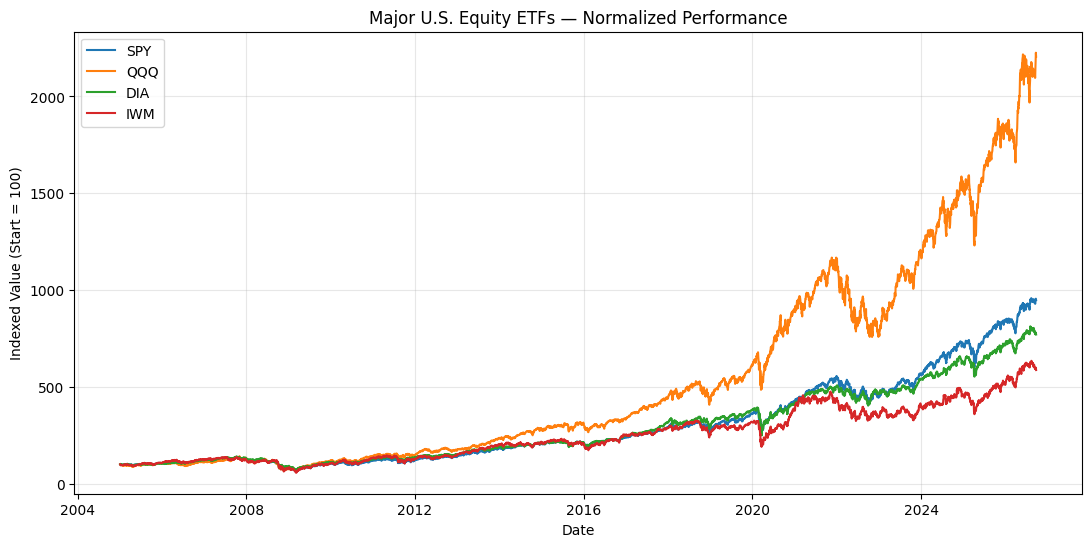

In [ ]:
# Plot major equity ETFs

plot_tickers = ["SPY", "QQQ", "DIA", "IWM"]

plt.figure(figsize=(13, 6))

for ticker in plot_tickers:
    if ticker in prices.columns:
        series = prices[ticker].dropna()
        normalized = series / series.iloc[0] * 100
        plt.plot(normalized, label=ticker)

plt.title("Major U.S. Equity ETFs — Normalized Performance")
plt.xlabel("Date")
plt.ylabel("Indexed Value (Start = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. Macroeconomic variables

The notebook pulls several FRED series:

- Federal Funds Rate
- 10-Year Treasury Yield
- CPI
- Unemployment
- Industrial Production
- Consumer Sentiment

For this educational model, macro observations are shifted one period before being forward-filled into daily data. A production-quality research system should use point-in-time/vintage data because economic statistics can be revised and publication dates differ from observation dates.


In [ ]:
FRED_SERIES = {
    "FedFunds": "DFF",
    "10Y": "DGS10",
    "CPI": "CPIAUCSL",
    "Unemployment": "UNRATE",
    "IndustrialProduction": "INDPRO",
    "ConsumerSentiment": "UMCSENT",
}


def fred_csv(series_id, start_date):
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv"
        f"?id={series_id}&cosd={start_date}"
    )

    df = pd.read_csv(url)

    df["observation_date"] = pd.to_datetime(
        df["observation_date"]
    )

    df = df.set_index("observation_date")

    df[series_id] = pd.to_numeric(
        df[series_id],
        errors="coerce"
    )

    return df[series_id]


macro = pd.DataFrame()

for name, series_id in FRED_SERIES.items():
    try:
        macro[name] = fred_csv(
            series_id,
            START_DATE
        )

        print(
            f"Downloaded {name} ({series_id})"
        )

    except Exception as e:
        print(
            f"Could not download {name}: {e}"
        )

macro = macro.sort_index()

display(macro.tail())


Downloaded FedFunds (DFF)
Downloaded 10Y (DGS10)
Downloaded CPI (CPIAUCSL)
Downloaded Unemployment (UNRATE)
Downloaded IndustrialProduction (INDPRO)
Downloaded ConsumerSentiment (UMCSENT)


,FedFunds,10Y,CPI,Unemployment,IndustrialProduction,ConsumerSentiment
observation_date,,,,,,
2026-09-18,3.88,5.01,NaN,NaN,NaN,NaN
2026-09-19,3.88,NaN,NaN,NaN,NaN,NaN
2026-09-20,3.88,NaN,NaN,NaN,NaN,NaN
2026-09-21,3.88,4.96,NaN,NaN,NaN,NaN
2026-09-22,3.88,4.96,NaN,NaN,NaN,NaN


In [ ]:
# Create macro-derived features

macro_features = pd.DataFrame(index=macro.index)

macro_features["FedFunds"] = macro["FedFunds"]
macro_features["10Y"] = macro["10Y"]
macro_features["Unemployment"] = macro["Unemployment"]
macro_features["ConsumerSentiment"] = macro["ConsumerSentiment"]

# Year-over-year growth
macro_features["CPI_yoy"] = macro["CPI"].pct_change(12)
macro_features["IndustrialProduction_yoy"] = (
    macro["IndustrialProduction"].pct_change(12)
)

# Simple yield-curve proxy
macro_features["10Y_minus_FedFunds"] = (
    macro["10Y"] - macro["FedFunds"]
)

# Conservative lag
macro_features = macro_features.shift(1)

# Convert to daily observations
macro_daily = macro_features.resample("D").ffill()

display(macro_daily.tail())


,FedFunds,10Y,Unemployment,ConsumerSentiment,CPI_yoy,IndustrialProduction_yoy,10Y_minus_FedFunds
observation_date,,,,,,,
2026-09-18,3.88,4.94,NaN,NaN,0.0,0.0,1.06
2026-09-19,3.88,5.01,NaN,NaN,0.0,0.0,1.13
2026-09-20,3.88,NaN,NaN,NaN,0.0,0.0,NaN
2026-09-21,3.88,NaN,NaN,NaN,0.0,0.0,NaN
2026-09-22,3.88,4.96,NaN,NaN,0.0,0.0,1.08


## 4. Volatility variables

We use:

- VIX
- 5-day realized SPY volatility
- 20-day realized SPY volatility
- 60-day realized SPY volatility
- 5-day VIX change


In [ ]:
vix = prices["^VIX"].rename("VIX")

spy_returns = prices["SPY"].pct_change()

vol_features = pd.DataFrame(index=prices.index)

vol_features["VIX"] = vix
vol_features["VIX_change_5d"] = vix.pct_change(5)

vol_features["SPY_vol_5d"] = (
    spy_returns.rolling(5).std() * np.sqrt(252)
)

vol_features["SPY_vol_20d"] = (
    spy_returns.rolling(20).std() * np.sqrt(252)
)

vol_features["SPY_vol_60d"] = (
    spy_returns.rolling(60).std() * np.sqrt(252)
)

display(vol_features.tail())


,VIX,VIX_change_5d,SPY_vol_5d,SPY_vol_20d,SPY_vol_60d
Date,,,,,
2026-09-18,14.81,-0.065025,0.109545,0.090530,0.113097
2026-09-21,14.87,-0.130409,0.145901,0.105380,0.115871
2026-09-22,NaN,-0.135465,0.132586,0.105039,0.111343
2026-09-23,15.18,-0.142857,0.145539,0.108665,0.111550
2026-09-24,15.65,0.013601,0.132240,0.106095,0.111497


## 5. Feature engineering

Each asset contributes:

- 1-day return
- 5-day return
- 20-day return
- Distance from 20-day moving average
- Distance from 50-day moving average
- Volume ratio

The target is the next trading day's SPY return.


In [ ]:
def create_market_dataset(
    prices,
    volumes,
    macro_daily,
    vol_features
):
    df = pd.DataFrame(index=prices.index)

    returns = prices.pct_change()

    for ticker in prices.columns:

        # Returns
        df[f"{ticker}_ret1"] = returns[ticker]
        df[f"{ticker}_ret5"] = prices[ticker].pct_change(5)
        df[f"{ticker}_ret20"] = prices[ticker].pct_change(20)

        # Moving-average trends
        sma20 = prices[ticker].rolling(20).mean()
        sma50 = prices[ticker].rolling(50).mean()

        df[f"{ticker}_vs_sma20"] = (
            prices[ticker] / sma20 - 1
        )

        df[f"{ticker}_vs_sma50"] = (
            prices[ticker] / sma50 - 1
        )

        # Volume
        if ticker in volumes.columns:
            df[f"{ticker}_volume_ratio"] = (
                volumes[ticker]
                / volumes[ticker].rolling(20).mean()
            )

    # Add macro variables
    df = df.join(
        macro_daily,
        how="left"
    )

    # Add volatility variables
    df = df.join(
        vol_features,
        how="left"
    )

    # Next-day SPY return = prediction target
    df["target"] = returns["SPY"].shift(-1)

    return df


dataset = create_market_dataset(
    prices,
    volumes,
    macro_daily,
    vol_features
)

print("Raw dataset shape:", dataset.shape)

display(dataset.tail())


Raw dataset shape: (5468, 139)


,DIA_ret1,DIA_ret5,DIA_ret20,DIA_vs_sma20,DIA_vs_sma50,DIA_volume_ratio,EEM_ret1,EEM_ret5,EEM_ret20,EEM_vs_sma20,...,ConsumerSentiment,CPI_yoy,IndustrialProduction_yoy,10Y_minus_FedFunds,VIX,VIX_change_5d,SPY_vol_5d,SPY_vol_20d,SPY_vol_60d,target
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-18,-0.002471,-0.016586,-0.028467,NaN,NaN,NaN,0.001793,-0.011940,-0.001341,NaN,...,NaN,0.0,0.0,1.06,14.81,-0.065025,0.109545,0.090530,0.113097,0.015505
2026-09-21,0.007560,-0.006696,-0.023746,NaN,NaN,NaN,0.026854,0.043037,0.041144,NaN,...,NaN,0.0,0.0,NaN,14.87,-0.130409,0.145901,0.105380,0.115871,-0.000155
2026-09-22,0.000000,-0.000483,-0.026646,NaN,NaN,NaN,0.000000,0.046685,0.023494,NaN,...,NaN,0.0,0.0,1.08,NaN,-0.135465,0.132586,0.105039,0.111343,-0.007202
2026-09-23,-0.010543,0.000515,-0.035087,NaN,NaN,NaN,-0.016272,0.030280,0.008039,NaN,...,NaN,NaN,NaN,NaN,15.18,-0.142857,0.145539,0.108665,0.111550,-0.000352
2026-09-24,-0.002333,-0.007847,-0.039119,NaN,NaN,NaN,-0.002584,0.009341,-0.001109,NaN,...,NaN,NaN,NaN,NaN,15.65,0.013601,0.132240,0.106095,0.111497,NaN


## 6. Robust data cleaning

This is the important fix for the previous error.

The old version used:

```python
dataset = dataset.ffill().dropna()
```

With many assets and macro variables, `dropna()` can remove almost every row.

Instead, we:

1. Remove completely empty columns.
2. Convert everything to numeric.
3. Replace infinite values.
4. Forward-fill information that is legitimately carried forward.
5. Require only the target to exist.
6. Fill remaining feature gaps using feature medians.
7. Check the resulting sample count before training.


In [ ]:
# ============================================================
# ROBUST DATA CLEANING
# ============================================================

print("Dataset BEFORE cleaning:")
print("Shape:", dataset.shape)

# ------------------------------------------------------------
# 1. Remove columns containing no observations whatsoever
# ------------------------------------------------------------

all_nan_cols = dataset.columns[
    dataset.isna().all()
].tolist()

if all_nan_cols:
    print("Removing completely empty columns:")
    print(all_nan_cols)

    dataset = dataset.drop(
        columns=all_nan_cols
    )

# ------------------------------------------------------------
# 2. Force numeric values
# ------------------------------------------------------------

dataset = dataset.apply(
    pd.to_numeric,
    errors="coerce"
)

# ------------------------------------------------------------
# 3. Replace infinite values
# ------------------------------------------------------------

dataset = dataset.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------------------
# 4. Forward-fill historical information
# ------------------------------------------------------------

dataset = dataset.ffill()

# ------------------------------------------------------------
# 5. The target MUST exist
# ------------------------------------------------------------

dataset = dataset.dropna(
    subset=["target"]
)

# ------------------------------------------------------------
# 6. Fill remaining feature gaps
# ------------------------------------------------------------

feature_columns_temp = [
    c for c in dataset.columns
    if c != "target"
]

dataset[feature_columns_temp] = (
    dataset[feature_columns_temp]
    .fillna(
        dataset[feature_columns_temp].median()
    )
)

# ------------------------------------------------------------
# 7. Final safety checks
# ------------------------------------------------------------

dataset = dataset.replace(
    [np.inf, -np.inf],
    np.nan
)

dataset = dataset.dropna(
    subset=["target"]
)

print()
print("Dataset AFTER cleaning:")
print("Shape:", dataset.shape)

print()
print("Date range:")
print("Start:", dataset.index.min())
print("End:", dataset.index.max())

print()
print("Number of features:")
print(len(feature_columns_temp))

print()
print("Missing target values:")
print(dataset["target"].isna().sum())

print()
print("Missing feature values:")
print(
    dataset[feature_columns_temp]
    .isna()
    .sum()
    .sum()
)

Dataset BEFORE cleaning:
Shape: (5468, 139)
Removing completely empty columns:
['^VIX_volume_ratio']

Dataset AFTER cleaning:
Shape: (5468, 138)

Date range:
Start: 2005-01-03 00:00:00
End: 2026-09-24 00:00:00

Number of features:
137

Missing target values:
0

Missing feature values:
0


In [ ]:
# ============================================================
# DATASET SANITY CHECK
# ============================================================

if len(dataset) <= TEST_DAYS:
    raise ValueError(
        f"Only {len(dataset)} usable observations remain, "
        f"but TEST_DAYS={TEST_DAYS}. "
        "Reduce TEST_DAYS or increase the available history."
    )

if dataset["target"].isna().any():
    raise ValueError(
        "The target still contains missing values."
    )

if np.isinf(
    dataset.select_dtypes(
        include=np.number
    ).to_numpy()
).any():
    raise ValueError(
        "Infinite values remain in the dataset."
    )

print("✓ Dataset passed sanity checks.")


✓ Dataset passed sanity checks.


In [ ]:
# Correlation inspection

correlations = (
    dataset
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values()
)

print("Most negative correlations:")
display(correlations.head(10))

print("Most positive correlations:")
display(correlations.tail(10))


Most negative correlations:


,target
XLV_ret1,-0.112263
DIA_ret1,-0.104646
SPY_ret1,-0.103788
XLE_ret1,-0.103053
XLU_ret1,-0.092608
EFA_ret1,-0.090124
XLU_ret5,-0.088136
XLB_ret1,-0.087887
XLP_ret5,-0.086420
XLK_ret1,-0.084765


Most positive correlations:


,target
^VIX_vs_sma50,0.032957
TLT_ret20,0.035290
TLT_ret1,0.038252
^VIX_vs_sma20,0.039357
TLT_ret5,0.040964
TLT_vs_sma20,0.041076
VIX,0.043079
VIX_change_5d,0.046221
^VIX_ret5,0.046221
^VIX_ret1,0.052404


## 7. Train/test split and Ridge model

The split is chronological. We do **not** randomly shuffle market observations.


In [ ]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

feature_cols = [
    c for c in dataset.columns
    if c != "target"
]

train = dataset.iloc[:-TEST_DAYS].copy()
test = dataset.iloc[-TEST_DAYS:].copy()

print("Training observations:", len(train))
print("Testing observations: ", len(test))
print("Features:             ", len(feature_cols))

# ============================================================
# MODEL
# ============================================================

model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "ridge",
        Ridge(alpha=10.0)
    )
])

model.fit(
    train[feature_cols],
    train["target"]
)

# ============================================================
# PREDICTIONS
# ============================================================

test_predictions = model.predict(
    test[feature_cols]
)

actual = test["target"].to_numpy()

# ============================================================
# EVALUATION
# ============================================================

mae = mean_absolute_error(
    actual,
    test_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        test_predictions
    )
)

direction_accuracy = np.mean(
    np.sign(test_predictions)
    == np.sign(actual)
)

print()
print("=" * 55)
print("MODEL RESULTS")
print("=" * 55)

print(
    f"Test observations:  {len(test):,}"
)

print(
    f"MAE:                {mae:.4%}"
)

print(
    f"RMSE:               {rmse:.4%}"
)

print(
    f"Direction accuracy: {direction_accuracy:.1%}"
)


Training observations: 5216
Testing observations:  252
Features:              137

MODEL RESULTS
Test observations:  252
MAE:                0.6796%
RMSE:               0.8803%
Direction accuracy: 47.6%


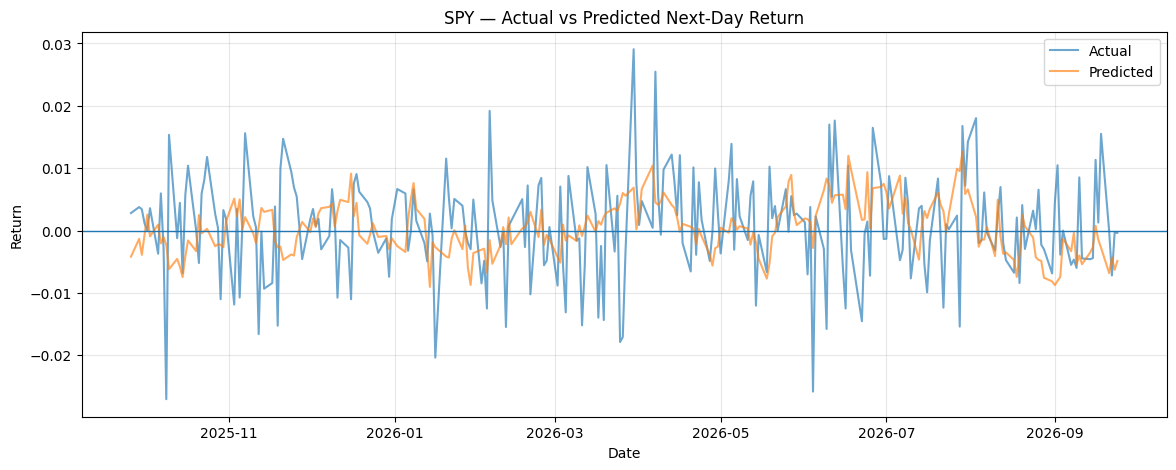

In [ ]:
# Actual vs predicted returns

plt.figure(figsize=(14, 5))

plt.plot(
    test.index,
    actual,
    label="Actual",
    alpha=0.65
)

plt.plot(
    test.index,
    test_predictions,
    label="Predicted",
    alpha=0.65
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "SPY — Actual vs Predicted Next-Day Return"
)

plt.xlabel("Date")
plt.ylabel("Return")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


## 8. Strategy backtest

The model generates a simple long/cash strategy:

- Positive prediction → hold SPY
- Non-positive prediction → hold cash
- Slippage and commission are charged whenever the position changes

The benchmark is buy-and-hold SPY over the exact same test period.


In [ ]:
# ============================================================
# BACKTEST
# ============================================================

backtest = test[["target"]].copy()

backtest["prediction"] = test_predictions

# Long / cash signal
backtest["signal"] = (
    backtest["prediction"]
    > PREDICTION_THRESHOLD
).astype(float)

# Strategy return
backtest["gross_strategy_return"] = (
    backtest["signal"]
    * backtest["target"]
)

# Position changes
backtest["trade"] = (
    backtest["signal"]
    .diff()
    .abs()
    .fillna(
        backtest["signal"].abs()
    )
)

# Transaction costs
backtest["transaction_cost"] = (
    backtest["trade"]
    * (COMMISSION + SLIPPAGE)
)

# Net strategy return
backtest["net_strategy_return"] = (
    backtest["gross_strategy_return"]
    - backtest["transaction_cost"]
)

# Benchmark
backtest["benchmark_return"] = (
    backtest["target"]
)

# Equity curves
backtest["strategy_equity"] = (
    INITIAL_CAPITAL
    * (
        1 + backtest["net_strategy_return"]
    ).cumprod()
)

backtest["benchmark_equity"] = (
    INITIAL_CAPITAL
    * (
        1 + backtest["benchmark_return"]
    ).cumprod()
)

display(backtest.tail())


,target,prediction,signal,gross_strategy_return,trade,transaction_cost,net_strategy_return,benchmark_return,strategy_equity,benchmark_equity
Date,,,,,,,,,,
2026-09-18,0.015505,-0.002739,0.0,0.0,0.0,0.0,0.0,0.015505,109562.061238,118135.592146
2026-09-21,-0.000155,-0.006827,0.0,-0.0,0.0,0.0,-0.0,-0.000155,109562.061238,118117.265457
2026-09-22,-0.007202,-0.004316,0.0,-0.0,0.0,0.0,-0.0,-0.007202,109562.061238,117266.565892
2026-09-23,-0.000352,-0.006285,0.0,-0.0,0.0,0.0,-0.0,-0.000352,109562.061238,117225.326180
2026-09-24,-0.000352,-0.004878,0.0,-0.0,0.0,0.0,-0.0,-0.000352,109562.061238,117184.100971


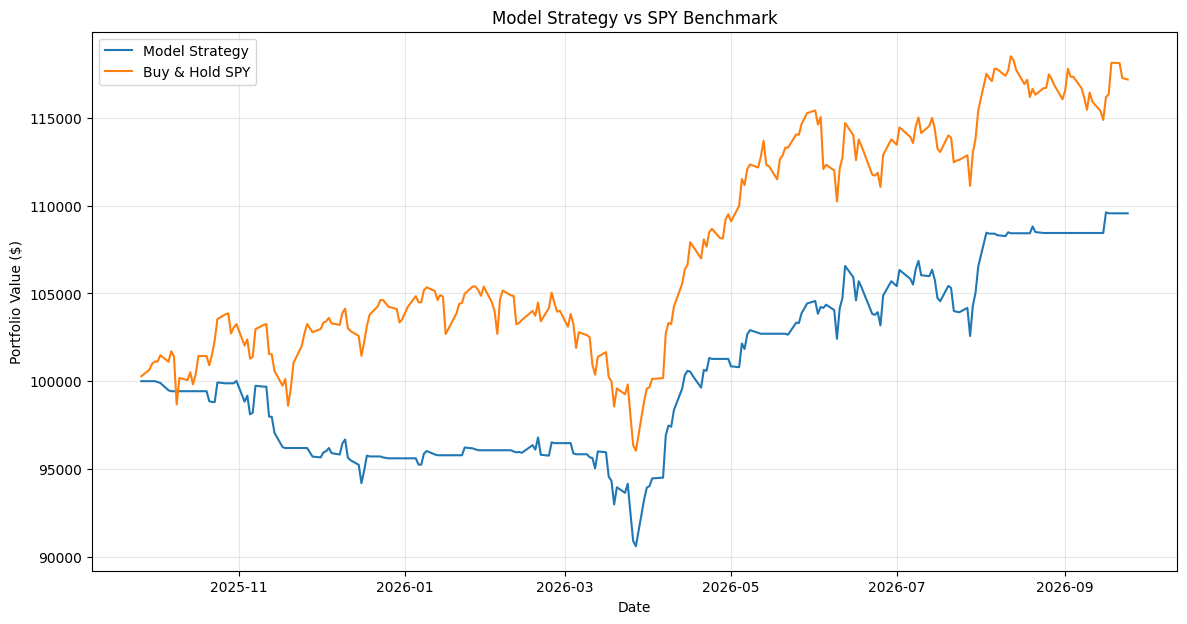

In [ ]:
# Strategy vs benchmark

plt.figure(figsize=(14, 7))

plt.plot(
    backtest.index,
    backtest["strategy_equity"],
    label="Model Strategy"
)

plt.plot(
    backtest.index,
    backtest["benchmark_equity"],
    label="Buy & Hold SPY"
)

plt.title(
    "Model Strategy vs SPY Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [ ]:
# ============================================================
# PERFORMANCE STATISTICS
# ============================================================

def performance_stats(
    returns,
    equity
):
    returns = returns.dropna()

    total_return = (
        equity.iloc[-1]
        / equity.iloc[0]
        - 1
    )

    years = len(returns) / 252

    annualized_return = (
        (1 + total_return)
        ** (1 / years)
        - 1
        if years > 0
        else np.nan
    )

    annualized_vol = (
        returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annualized_return
        / annualized_vol
        if annualized_vol != 0
        else np.nan
    )

    running_max = equity.cummax()

    drawdown = (
        equity / running_max
        - 1
    )

    max_drawdown = drawdown.min()

    win_rate = (
        returns > 0
    ).mean()

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_vol,
        "Sharpe (rf=0)": sharpe,
        "Max Drawdown": max_drawdown,
        "Daily Win Rate": win_rate
    }


strategy_stats = performance_stats(
    backtest["net_strategy_return"],
    backtest["strategy_equity"]
)

benchmark_stats = performance_stats(
    backtest["benchmark_return"],
    backtest["benchmark_equity"]
)

comparison = pd.DataFrame({
    "Model Strategy": strategy_stats,
    "Buy & Hold SPY": benchmark_stats
})

display(
    comparison.style.format("{:.2%}")
)


,Model Strategy,Buy & Hold SPY
Total Return,9.56%,16.86%
Annualized Return,9.56%,16.86%
Annualized Volatility,9.78%,12.94%
Sharpe (rf=0),97.73%,130.28%
Max Drawdown,-9.42%,-8.88%
Daily Win Rate,25.79%,52.78%


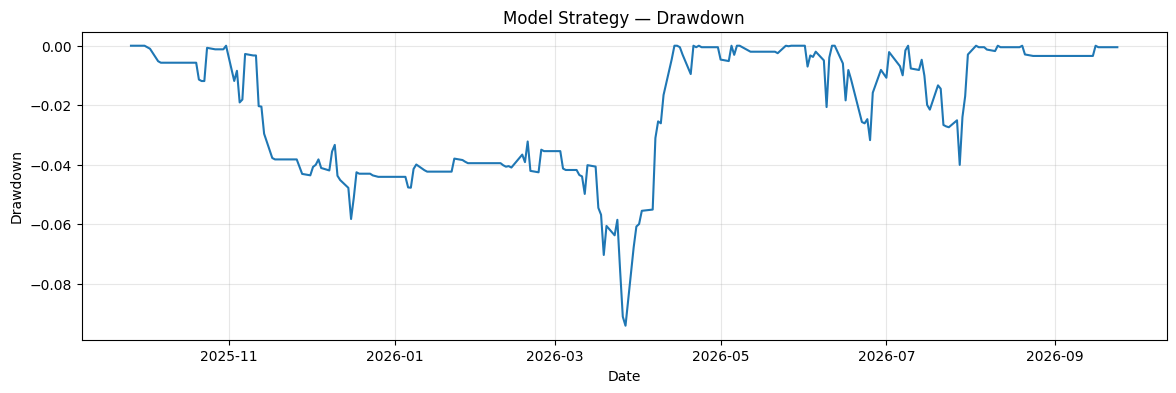

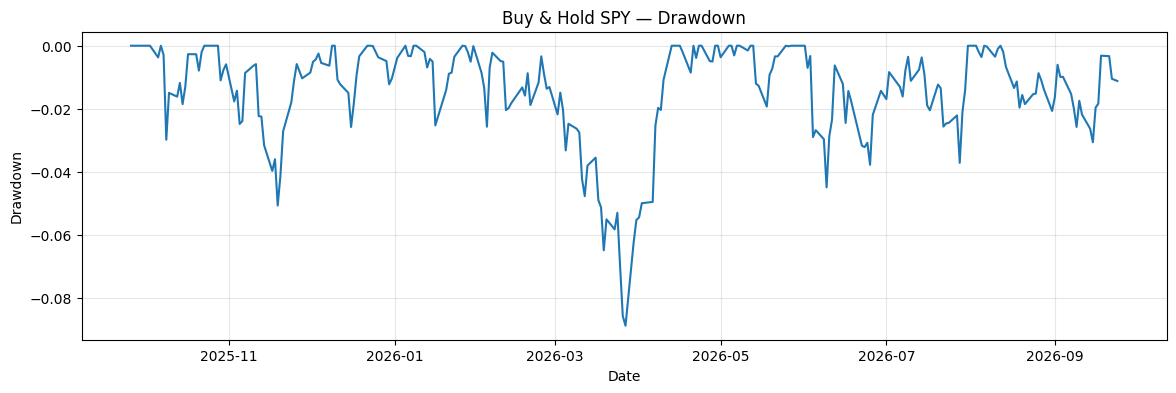

In [ ]:
# Drawdown comparison

for label, equity in [
    (
        "Model Strategy",
        backtest["strategy_equity"]
    ),
    (
        "Buy & Hold SPY",
        backtest["benchmark_equity"]
    )
]:

    drawdown = (
        equity
        / equity.cummax()
        - 1
    )

    plt.figure(figsize=(14, 4))

    plt.plot(
        drawdown.index,
        drawdown
    )

    plt.title(
        f"{label} — Drawdown"
    )

    plt.ylabel("Drawdown")
    plt.xlabel("Date")

    plt.grid(alpha=0.3)

    plt.show()


## 9. Feature coefficients

These Ridge coefficients show which standardized features have the strongest relationship with the model's predictions.

They should **not** be interpreted as causal effects.


In [ ]:
ridge_model = model.named_steps["ridge"]

coefficients = pd.Series(
    ridge_model.coef_,
    index=feature_cols
).sort_values()

print("Most negative coefficients:")
display(
    coefficients.head(15)
)

print("Most positive coefficients:")
display(
    coefficients.tail(15)
)


Most negative coefficients:


,0
SPY_ret5,-0.006363
SPY_vs_sma20,-0.005087
QQQ_ret20,-0.003132
XLB_vs_sma50,-0.001847
XLY_vs_sma50,-0.001830
DIA_ret20,-0.001784
^VIX_ret20,-0.001635
XLK_ret1,-0.001622
XLC_vs_sma50,-0.001582
EEM_vs_sma20,-0.001408


Most positive coefficients:


,0
QQQ_vs_sma20,0.001196
Unemployment,0.001208
XLP_ret20,0.001208
XLI_ret5,0.001211
XLY_ret20,0.001247
DIA_ret5,0.001258
XLY_ret5,0.001313
EEM_ret1,0.001376
XLI_vs_sma50,0.001516
SPY_vs_sma50,0.001561


## 10. Multiple passive benchmarks

The model can also be compared with buy-and-hold versions of other major ETFs over the same test period.


In [ ]:
benchmark_tickers = [
    "SPY",
    "QQQ",
    "DIA",
    "IWM",
    "TLT",
    "GLD"
]

benchmark_table = {}

for ticker in benchmark_tickers:

    if ticker not in prices.columns:
        continue

    r = (
        prices[ticker]
        .pct_change()
        .reindex(test.index)
        .dropna()
    )

    equity = (
        INITIAL_CAPITAL
        * (1 + r).cumprod()
    )

    benchmark_table[ticker] = performance_stats(
        r,
        equity
    )

benchmark_comparison = pd.DataFrame(
    benchmark_table
).T

display(
    benchmark_comparison.style.format("{:.2%}")
)


,Total Return,Annualized Return,Annualized Volatility,Sharpe (rf=0),Max Drawdown,Daily Win Rate
SPY,17.23%,17.23%,12.95%,133.04%,-8.88%,53.17%
QQQ,24.87%,24.87%,19.88%,125.07%,-11.96%,53.97%
DIA,12.63%,12.63%,12.65%,99.84%,-9.76%,54.37%
IWM,17.79%,17.79%,18.63%,95.50%,-11.03%,55.16%
TLT,-5.92%,-5.92%,9.28%,-63.85%,-9.59%,48.02%
GLD,12.95%,12.95%,29.30%,44.20%,-26.40%,55.56%


## 11. Slippage sensitivity

Backtests can be very sensitive to implementation assumptions.

Here we test the model under several slippage assumptions.


In [ ]:
slippage_values = [
    0.0000,
    0.00025,
    0.00050,
    0.00100,
    0.00200
]

slippage_results = []

for slip in slippage_values:

    r = backtest.copy()

    r["cost"] = (
        r["trade"]
        * (COMMISSION + slip)
    )

    r["net"] = (
        r["gross_strategy_return"]
        - r["cost"]
    )

    r["equity"] = (
        INITIAL_CAPITAL
        * (1 + r["net"]).cumprod()
    )

    stats = performance_stats(
        r["net"],
        r["equity"]
    )

    slippage_results.append({
        "Slippage": slip,
        **stats
    })

slippage_df = (
    pd.DataFrame(
        slippage_results
    )
    .set_index("Slippage")
)

display(
    slippage_df.style.format("{:.2%}")
)


,Total Return,Annualized Return,Annualized Volatility,Sharpe (rf=0),Max Drawdown,Daily Win Rate
Slippage,,,,,,
0.000000,13.12%,13.12%,9.77%,134.35%,-8.04%,26.19%
0.000250,11.33%,11.33%,9.78%,115.90%,-8.73%,25.79%
0.000500,9.56%,9.56%,9.78%,97.73%,-9.42%,25.79%
0.001000,6.11%,6.11%,9.81%,62.28%,-11.15%,25.40%
0.002000,-0.48%,-0.48%,9.90%,-4.81%,-14.56%,25.00%


## 12. Current model signal

The final model is retrained using all available observations and produces a next-day SPY return estimate.

This is a model output for research purposes, not a trading instruction.


In [ ]:
# ============================================================
# FINAL MODEL
# ============================================================

final_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "ridge",
        Ridge(alpha=10.0)
    )
])

final_model.fit(
    dataset[feature_cols],
    dataset["target"]
)

latest_features = (
    dataset[feature_cols]
    .iloc[[-1]]
)

next_return_prediction = float(
    final_model.predict(
        latest_features
    )[0]
)

print(
    f"Latest data date: "
    f"{dataset.index[-1].date()}"
)

print(
    f"Predicted next-day SPY return: "
    f"{next_return_prediction:+.3%}"
)

if next_return_prediction > PREDICTION_THRESHOLD:
    print("Model state: LONG / positive signal")
else:
    print("Model state: CASH / non-positive signal")


Latest data date: 2026-09-24
Predicted next-day SPY return: -0.333%
Model state: CASH / non-positive signal


# Important research limitations

1. **Point-in-time macro data:** FRED observations should ideally be aligned to their actual release dates/vintages.
2. **Walk-forward validation:** The model should be repeatedly retrained through history rather than using one fixed train/test split.
3. **Survivorship bias:** The current ETF universe consists of assets that exist today.
4. **Execution modeling:** Real slippage depends on liquidity, volatility, spread, and order size.
5. **Parameter selection:** Thresholds and Ridge alpha should be selected using training data only.
6. **Multiple testing:** Trying many models/features can create overfitting.
7. **Regime changes:** Relationships in financial markets can change substantially over time.
8. **Benchmark selection:** Different objectives require different benchmarks.

